# Book Recommendation System Using Information Retrieval

This notebook builds a simple book recommendation system using TF-IDF and cosine similarity. It is designed to be beginner-friendly.

## Workflow

1. Import libraries
2. Load dataset
3. Clean missing values
4. Group reviews by title
5. Preprocess text
6. Apply TF-IDF vectorization
7. Compute cosine similarity
8. Create recommendation function
9. Test the system with example queries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from book_recommender import build_recommender, recommend_books, download_nltk_resources

In [18]:
download_nltk_resources()

DATASET_PATH = Path('anotherOne.csv')
RAW_DF = pd.read_csv(DATASET_PATH)
RAW_DF.head()

,Unnamed: 0,Id,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
0,0,0671551345,Night World: Daughters Of Darkness,1.00,5,This book is one of my favorates.,I have read just about everything L.J. Smith h...,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
1,1,0671551345,Night World: Daughters Of Darkness,1.00,5,My favorite of all her books!!!!!!!,"This is the best book L.J. has written, and I'...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
2,2,0671551345,Night World: Daughters Of Darkness,0.75,5,Second Book in the Night World Series,"Set in Briar Creek, Oregon, ""Daughters of Dark...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
3,3,0671551345,Night World: Daughters Of Darkness,0.70,5,This book had me giggling,"I'm sorry, but I just find the way Mary Lennet...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
4,4,0671551345,Night World: Daughters Of Darkness,1.00,5,One of the best books I've ever read!,DAUGHTERS OF DARKNESS was the first book by L....,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11


## Load Dataset and Basic Information

In [19]:
print('Dataset shape before cleaning:', RAW_DF.shape)
print('\nColumns in dataset:')
print(list(RAW_DF.columns))

Dataset shape before cleaning: (278277, 12)

Columns in dataset:
['Unnamed: 0', 'Id', 'Title', 'review/helpfulness', 'review/score', 'review/summary', 'review/text', 'description', 'authors', 'publisher', 'categories', 'ratingsCount']


## Data Cleaning

In [20]:
clean_df = RAW_DF.fillna('')
print('Missing values after filling NaN with empty strings:')
print(clean_df[['Title', 'review/summary', 'review/text', 'description', 'authors', 'publisher', 'review/score', 'categories']].isna().sum())

Missing values after filling NaN with empty strings:
Title             0
review/summary    0
review/text       0
description       0
authors           0
publisher         0
review/score      0
categories        0
dtype: int64


## Build the Recommender Artifacts

The helper module handles review grouping, content creation, preprocessing, TF-IDF vectorization, and cosine similarity.

In [21]:
artifacts = build_recommender(str(DATASET_PATH), nrows=50000)
books_df = artifacts.books_df

print('Number of unique books after grouping by title:', books_df.shape[0])
books_df[['Title', 'Author' if 'Author' in books_df.columns else 'authors', 'categories', 'rating_score']].head()

Number of unique books after grouping by title: 407


,Title,authors,categories,rating_score
0,Night World: Daughters Of Darkness,L.J. Smith,Juvenile Fiction,4.85
1,From Potter's Field,Patricia Cornwell,Fiction,3.50
2,Economics in one lesson,Henry Hazlitt,Business & Economics,4.85
3,The Castle in the Attic,Elizabeth Winthrop,Juvenile Fiction,4.75
4,Dr. Bernstein's Diabetes Solution: The Complet...,Richard K. Bernstein,Health & Fitness,4.91


## Grouped Book-Level Data

In [22]:
books_df[['Title', 'authors', 'publisher', 'categories', 'rating_score']].head(10)

,Title,authors,publisher,categories,rating_score
0,Night World: Daughters Of Darkness,L.J. Smith,Simon and Schuster,Juvenile Fiction,4.85
1,From Potter's Field,Patricia Cornwell,Hachette UK,Fiction,3.50
2,Economics in one lesson,Henry Hazlitt,Currency,Business & Economics,4.85
3,The Castle in the Attic,Elizabeth Winthrop,Holiday House,Juvenile Fiction,4.75
4,Dr. Bernstein's Diabetes Solution: The Complet...,Richard K. Bernstein,Hachette UK,Health & Fitness,4.91
5,Mothman Prophecies,John A. Keel,Hachette UK,"Body, Mind & Spirit",4.18
6,"Prodigal Son (Dean Koontz's Frankenstein, Book 1)",Dean Koontz,HarperCollins UK,Fiction,4.10
7,King Rat,James Clavell,Blackstone Publishing,Fiction,4.69
8,Helter Skelter,"Vincent Bugliosi, Curt Gentry",Random House,True Crime,4.85
9,Small Gods,Terry Pratchett,Random House,Fiction,4.82


## Combined Content Column

In [23]:
books_df[['Title', 'content', 'processed_content']].head(3)

,Title,content,processed_content
0,Night World: Daughters Of Darkness,Night World: Daughters Of Darkness L.J. Smith ...,night world daughter darkness lj smith book on...
1,From Potter's Field,From Potter's Field Patricia Cornwell Meeting ...,potter field patricia cornwell meeting parent ...
2,Economics in one lesson,Economics in one lesson Henry Hazlitt The most...,economics one lesson henry hazlitt amazing boo...


## TF-IDF Matrix and Cosine Similarity

In [24]:
print('TF-IDF matrix shape:', artifacts.tfidf_matrix.shape)
print('Cosine similarity matrix shape:', artifacts.similarity_matrix.shape)

TF-IDF matrix shape: (407, 10000)
Cosine similarity matrix shape: (407, 407)


## Optional Visualization

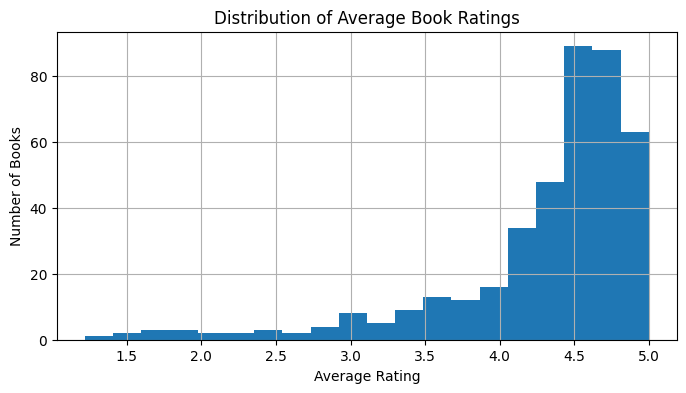

In [25]:
plt.figure(figsize=(8, 4))
books_df['rating_score'].hist(bins=20)
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.show()

## Recommendation Function

In [26]:
query = 'The Hobbit'
recommend_books(query, artifacts, top_n=5)

,Query,Title,Author,Genre,Rating Score,Top Reviews
0,The Hobbit,The Fellowship of the Ring,J.R.R. Tolkien,Fiction,4.78,[Anyone even remotely interested in fanstasy t...
1,The Hobbit,The Lord of the Rings - Boxed Set,J.R.R. Tolkien,Young Adult Fiction,4.58,[I too have read The Hobbit/LOTR countless tim...
2,The Hobbit,The teachings of Don Juan: a yaqui Way of Know...,Carlos Castaneda,Social Science,4.34,"[Man, to keep it simple, this book explains so..."
3,The Hobbit,How to Read a Book,George Samuel Clason,Political Science,4.64,[I thought I knew how to read well until I rea...
4,The Hobbit,Blood of the Fold (Sword of Truth Series),Terry Goodkind,Good and evil,3.63,"[I will try to be the mediator here. Please, t..."


## Testing Examples

In [27]:
test_queries = [
    'The Hobbit',
    'L.J. Smith',
    'Juvenile Fiction',
    'vampire romance adventure',
    ''
]

for item in test_queries:
    print(f'\nQuery: {item!r}')
    display(recommend_books(item, artifacts, top_n=5))


Query: 'The Hobbit'


,Query,Title,Author,Genre,Rating Score,Top Reviews
0,The Hobbit,The Fellowship of the Ring,J.R.R. Tolkien,Fiction,4.78,[Anyone even remotely interested in fanstasy t...
1,The Hobbit,The Lord of the Rings - Boxed Set,J.R.R. Tolkien,Young Adult Fiction,4.58,[I too have read The Hobbit/LOTR countless tim...
2,The Hobbit,The teachings of Don Juan: a yaqui Way of Know...,Carlos Castaneda,Social Science,4.34,"[Man, to keep it simple, this book explains so..."
3,The Hobbit,How to Read a Book,George Samuel Clason,Political Science,4.64,[I thought I knew how to read well until I rea...
4,The Hobbit,Blood of the Fold (Sword of Truth Series),Terry Goodkind,Good and evil,3.63,"[I will try to be the mediator here. Please, t..."



Query: 'L.J. Smith'


,Query,Title,Author,Genre,Rating Score,Top Reviews
0,L.J. Smith,Night World: Daughters Of Darkness,L.J. Smith,Juvenile Fiction,4.85,[I have read just about everything L.J. Smith ...



Query: 'Juvenile Fiction'


,Query,Title,Author,Genre,Rating Score,Top Reviews
0,Juvenile Fiction,Into the Wild (Warriors),Erin Hunter,Juvenile Fiction,4.94,[This is the best book ever!! I read it like t...
1,Juvenile Fiction,Mossflower,Brian Jacques,Juvenile Fiction,4.92,[This is only the second book I've read in the...
2,Juvenile Fiction,The cat in the hat,Dr. Seuss,Juvenile Fiction,4.92,"[Always a great book, to read again and again!..."
3,Juvenile Fiction,My Truck is Stuck!,Kevin Lewis,Juvenile Fiction,4.91,"[""My Truck is Stuck"" is a fabulous book and fu..."
4,Juvenile Fiction,Dr Seusss Sleep Book,Dr. Seuss,Juvenile Fiction,4.90,[My son received this book as a gift when he w...



Query: 'vampire romance adventure'


,Query,Title,Author,Genre,Rating Score,Top Reviews
0,vampire romance adventure,Shattered Mirror (Den of Shadows),Amelia Atwater-Rhodes,Young Adult Fiction,3.98,[The book by Amelia Atwater contains a story l...
1,vampire romance adventure,THE VAMPIRE LESTAT,Anne Rice,Fiction,4.53,[The second installment of Anne Rice's Vampire...
2,vampire romance adventure,Demon in My View (Den of Shadows),Amelia Atwater-Rhodes,Young Adult Fiction,3.32,[When my reading class decided to read a vampi...
3,vampire romance adventure,I am Legend,Richard Matheson,Horror tales,4.59,"[A friend of mine lent me this book, and it tu..."
4,vampire romance adventure,"Circus Of The Damned (Anita Blake, Vampire Hun...",Laurell K. Hamilton,Fiction,4.28,[Fantastic read. I couldn't guess the end the ...



Query: ''


,message
0,"Please enter a book title, author, genre, or k..."


In [28]:
RAW_DF.head()

,Unnamed: 0,Id,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
0,0,0671551345,Night World: Daughters Of Darkness,1.00,5,This book is one of my favorates.,I have read just about everything L.J. Smith h...,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
1,1,0671551345,Night World: Daughters Of Darkness,1.00,5,My favorite of all her books!!!!!!!,"This is the best book L.J. has written, and I'...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
2,2,0671551345,Night World: Daughters Of Darkness,0.75,5,Second Book in the Night World Series,"Set in Briar Creek, Oregon, ""Daughters of Dark...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
3,3,0671551345,Night World: Daughters Of Darkness,0.70,5,This book had me giggling,"I'm sorry, but I just find the way Mary Lennet...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
4,4,0671551345,Night World: Daughters Of Darkness,1.00,5,One of the best books I've ever read!,DAUGHTERS OF DARKNESS was the first book by L....,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11


In [29]:
RAW_DF.shape

(278277, 12)

In [30]:
RAW_DF.columns

Index(['Unnamed: 0', 'Id', 'Title', 'review/helpfulness', 'review/score',
       'review/summary', 'review/text', 'description', 'authors', 'publisher',
       'categories', 'ratingsCount'],
      dtype='str')

In [31]:
clean_df.head()

,Unnamed: 0,Id,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
0,0,0671551345,Night World: Daughters Of Darkness,1.00,5,This book is one of my favorates.,I have read just about everything L.J. Smith h...,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
1,1,0671551345,Night World: Daughters Of Darkness,1.00,5,My favorite of all her books!!!!!!!,"This is the best book L.J. has written, and I'...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
2,2,0671551345,Night World: Daughters Of Darkness,0.75,5,Second Book in the Night World Series,"Set in Briar Creek, Oregon, ""Daughters of Dark...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
3,3,0671551345,Night World: Daughters Of Darkness,0.70,5,This book had me giggling,"I'm sorry, but I just find the way Mary Lennet...","""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11
4,4,0671551345,Night World: Daughters Of Darkness,1.00,5,One of the best books I've ever read!,DAUGHTERS OF DARKNESS was the first book by L....,"""There’s something strange about the new girls...",['L.J. Smith'],Simon and Schuster,Juvenile Fiction,11


In [32]:
books_df.head()

,Title,authors,publisher,description,categories,review/summary,review/text,rating_score,top_reviews,content,processed_content
0,Night World: Daughters Of Darkness,L.J. Smith,Simon and Schuster,"""There’s something strange about the new girls...",Juvenile Fiction,This book is one of my favorates. My favorite ...,I have read just about everything L.J. Smith h...,4.85,[I have read just about everything L.J. Smith ...,Night World: Daughters Of Darkness L.J. Smith ...,night world daughter darkness lj smith book on...
1,From Potter's Field,Patricia Cornwell,Hachette UK,"The sixth book in the Kay Scarpetta series, fr...",Fiction,Meeting the Parents of a Serial Killer Cornwel...,Another great book from Madame Medical Investi...,3.50,[Another great book from Madame Medical Invest...,From Potter's Field Patricia Cornwell Meeting ...,potter field patricia cornwell meeting parent ...
2,Economics in one lesson,Henry Hazlitt,Currency,"With over a million copies sold, Economics in ...",Business & Economics,The most amazing book!!! Recommended Reading f...,"I am a homeschooler, I and am 16, I used to ha...",4.85,"[I am a homeschooler, I and am 16, I used to h...",Economics in one lesson Henry Hazlitt The most...,economics one lesson henry hazlitt amazing boo...
3,The Castle in the Attic,Elizabeth Winthrop,Holiday House,The classic children's story about a young boy...,Juvenile Fiction,So Awesome!! Away We Go! The Best Book Ever A ...,"Man, this book was neat. I loved it. The Castl...",4.75,"[Man, this book was neat. I loved it. The Cast...",The Castle in the Attic Elizabeth Winthrop So ...,castle attic elizabeth winthrop awesome away g...
4,Dr. Bernstein's Diabetes Solution: The Complet...,Richard K. Bernstein,Hachette UK,"Originally published in 1997, DR. BERNSTEIN'S ...",Health & Fitness,"The ""Bible"" for Diabetics! Changed My Life If ...","This book is absolutely amazing, I am stunned ...",4.91,"[This book is absolutely amazing, I am stunned...",Dr. Bernstein's Diabetes Solution: The Complet...,dr bernstein diabetes solution complete guide ...
